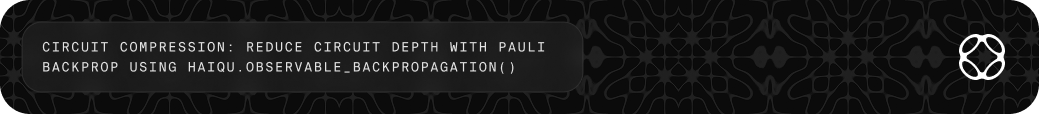

This notebook demonstrates how to reduce the size of your quantum circuits with classical Pauli backpropagation using `haiqu.observable_backpropagation()`.

- Observable backpropagation reduces the number of the 2-qubit gates in a **193-qubit** Heisenberg time evolution circuit from **1344** to **496** for a single-qubit observable
- This is done by significantly increasing the number (and often the weight) of Pauli terms in the measurement observable

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

### `haiqu.observable_backpropagation()`

- **What does it do?** Observable backpropagation shortens quantum circuits, improving performance on noisy quantum hardware, by classically simulating and incorporating a part of the circuit into the observable
- **How do I use it?** Pass a quantum circuit along with the observable you'd like to measure to `haiqu.observable_backpropagation()` to receive the optimized circuit and the updated observable.
- **What are the options?** Optional parameters include `max_qwc_groups`, `max_error_total`, `max_error_per_slice` for precise configuration and `log` specifying whether to save your circuits in Haiqu SDK.
- **Which option do you recommend?** Start with the default settings for most use cases. Change `max_qwc_groups` based on your quantum resources and `max_error_total`, `max_error_per_slice` for precise configuration of the admittable errors

## Initialize the benchmark

Import the necessary libraries, initialize the Haiqu SDK, and create a Heisenberg evolution circuit with almost 200 qubits and more than a thousand 2-qubit gates along with a corresponding observable.

In [1]:
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import CouplingMap
from qiskit.synthesis import LieTrotter
from qiskit_addon_utils.problem_generators import (
    generate_time_evolution_circuit,
    generate_xyz_hamiltonian,
)
from haiqu.sdk import haiqu

haiqu.login() # Login setup
haiqu.init("Observable backpropagation tutorial") # Initialize the experiment
 
coupling_map = CouplingMap.from_heavy_hex(9, bidirectional=False)
 
# Get a qubit operator describing the Heisenberg XYZ model
hamiltonian = generate_xyz_hamiltonian(
    coupling=coupling_map,
    coupling_constants=(np.pi / 8, np.pi / 4, np.pi / 2),
    ext_magnetic_field=(np.pi / 3, np.pi / 6, np.pi / 9),
)
 
# We evolve for some time
circuit = generate_time_evolution_circuit(
    hamiltonian, synthesis=LieTrotter(reps=2), time=0.2
)

# Specify a single-qubit observable
observable = SparsePauliOp("I" * (circuit.num_qubits - 1) + "Z")

logged_circuit = haiqu.log(circuit, name="Time evolution circuit")

logged_circuit.core_metrics()

CIRCUIT,Time evolution circuit
QUBITS,193
DEPTH,30
2-Q GATES DEPTH,24
1-Q GATES,1158
2-Q GATES,1344
GATES TOTAL,2502


## Run benchmark scenarios

We will now perform observable backpropagation on the Heisenberg evolution circuit and observable defined above and compare the original and optimized circuits. With default settings, optimization should run in under a minute. Increasing the `max_qwc_groups` parameter or lowering the acceptable approximation errors will allow for more aggressive optimization at the cost of longer runtime.

In [2]:
optimized_circuits, optimized_observables = haiqu.observable_backpropagation(logged_circuit, observable)

print(f"Original observable had {len(observable.paulis)} Pauli terms")
print(f"Optimized observable has {len(optimized_observables[0].paulis)} Pauli terms")

haiqu.compare_metrics(logged_circuit, optimized_circuits[0])

Original observable had 1 Pauli terms
Optimized observable has 143 Pauli terms


CIRCUIT,Time evolution circuit,obp-0-circuit-46
QUBITS,193,193
DEPTH,30,7
2-Q GATES DEPTH,24,7
1-Q GATES,1158,0
2-Q GATES,1344,496
GATES TOTAL,2502,496


> **💡 The optimized circuit has almost 3 times less 2-qubit gates! Such reduction will result in a significantly less noisy result when executing on a quantum hardware. Note that the resulting observable now has much more Pauli terms and will incur overhead in the number of circuit executions required.**

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

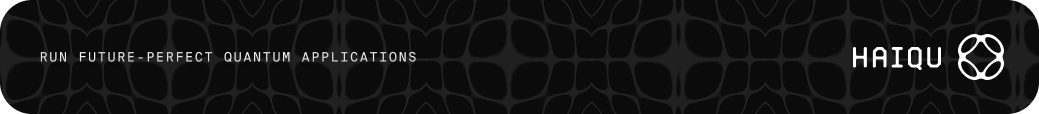